In [ ]:
# ============================================================
# Setup For Churn Model 
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, confusion_matrix, classification_report, 
                               roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/telco_cleaned.csv')
print(df.shape)

(7043, 20)


In [ ]:
# ============================================================
# ENCODING: Convert Yes/No columns to 1/0
# ============================================================
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# ============================================================
# Each category becomes its own binary column, enabling models to process categorical data
# ============================================================
categorical_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                     'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                     'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Avoiding Redundant Columns with "drop_first=True"

print(df_encoded.shape)
df_encoded.head()

(7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
# ============================================================
# X = everything the model uses to PREDICT
# y = what we're trying to predict (did they churn?)
# ============================================================

# Drop columns that aren't useful features  

drop_cols = ['Churn', 'churn_flag', 'tenure_cohort', 'ChargeBand']
drop_cols = [c for c in drop_cols if c in df_encoded.columns]  # safety check

X = df_encoded.drop(columns=drop_cols)
y = df_encoded['Churn']

print(X.shape, y.shape)

(7043, 30) (7043,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# stratify=y ensures both train and test sets have the same 
# ~26.5% churn ratio as the full dataset — avoids a lucky/unlucky split

print(f"Training on {X_train.shape[0]} customers, testing on {X_test.shape[0]}")

Training on 5634 customers, testing on 1409


In [ ]:
# Feature Scaling with StandardScaler
# Ensures numeric features have mean 0 and variance 1 for better model performance

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [ ]:
# Fitting Logistic Regression on Training Data 

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Accuracy: 0.806
Precision: 0.659
Recall: 0.559
F1 Score: 0.605
ROC-AUC: 0.842
[[927 108]
 [165 209]]


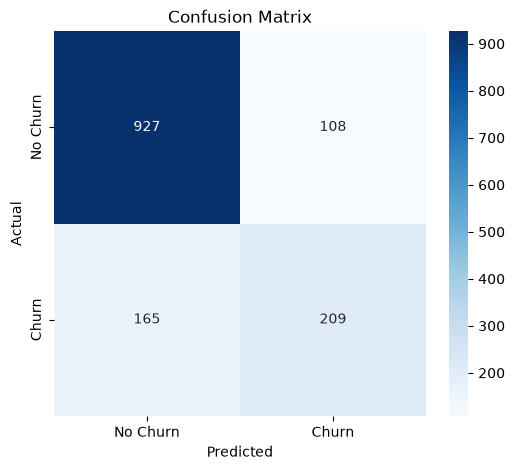

In [ ]:
# Model Performance Evaluation

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')

plt.savefig('../reports/figures/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Threshold Adjustment for Churn Prediction 

final_threshold = 0.35
y_pred_final = (y_proba >= final_threshold).astype(int)

print("Recall:", round(recall_score(y_test, y_pred_final), 3))
print("Precision:", round(precision_score(y_test, y_pred_final), 3))

Recall: 0.703
Precision: 0.545


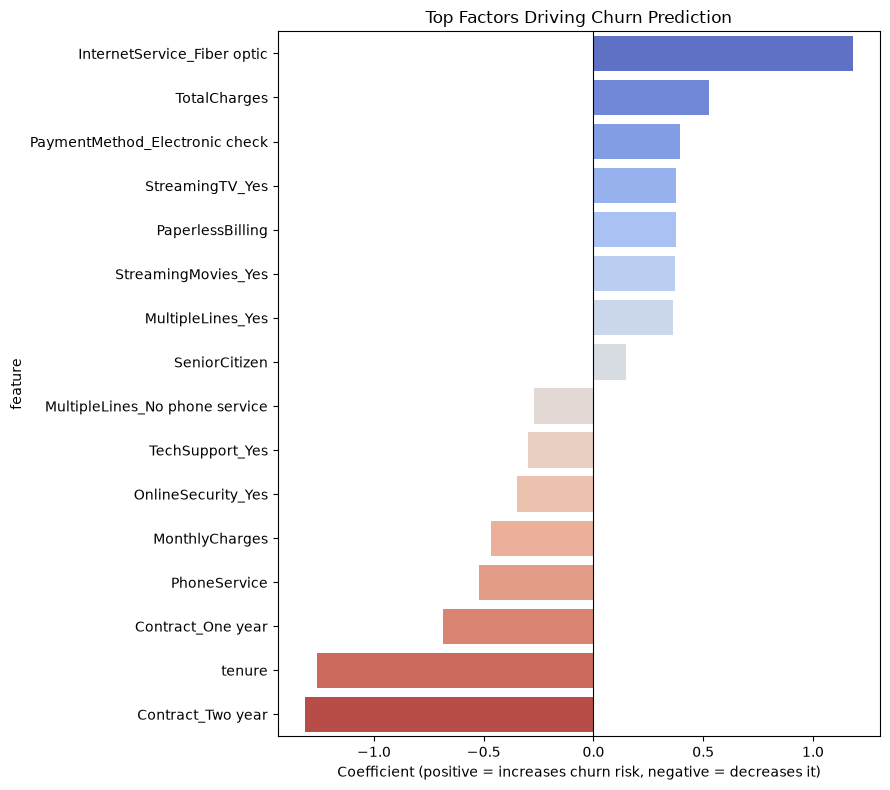

In [10]:
# ============================================================
# FEATURE IMPORTANCE — which factors mattered most to the model
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

# Take top 8 features that INCREASE churn risk, and top 8 that DECREASE it
top_features = pd.concat([coefficients.head(8), coefficients.tail(8)])

plt.figure(figsize=(9,8))
sns.barplot(data=top_features, x='coefficient', y='feature', hue='feature', palette='coolwarm', legend=False)
plt.title('Top Factors Driving Churn Prediction')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (positive = increases churn risk, negative = decreases it)')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
results = X_test.copy()
results['actual_churn'] = y_test.values
results['predicted_churn'] = y_pred_final
results['churn_probability'] = y_proba
results['MonthlyCharges_actual'] = df.loc[X_test.index, 'MonthlyCharges'].values

import os
os.makedirs('../data/processed', exist_ok=True)
results.to_csv('../data/processed/model_predictions.csv', index=False)
print("Saved.")

Saved.
